In [1]:
!pip install leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 33.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import fcluster
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import umap
from sklearn.metrics import silhouette_score
import matplotlib.colors as mcolors
import hdbscan
#import leidenalg
from sklearn.neighbors import NearestNeighbors
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
#import igraph as ig

In [3]:
df_iersin = pd.read_excel('/content/иерсин.xlsx', skiprows=1)
df_pseudo = pd.read_excel('/content/псевдик.xlsx', skiprows=1)
df_iersin = df_iersin.fillna(0)
df_iersin.columns = ['Регион'] + list(df_iersin.columns[1:])
df_iersin

,Регион,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,РФ,2.23,1.92,1.61,1.81,1.67,1.42,1.32,1.25,1.24,1.27,0.87,0.86,0.95,0.56,0.40,0.45,0.63,0.54
1,Белгородская область,0.99,1.12,0.59,0.20,1.37,1.63,0.45,0.19,0.39,0.32,0.13,0.32,0.77,0.32,0.13,0.00,0.13,0.20
2,Брянская область,1.13,1.83,2.45,6.17,1.96,0.63,0.48,0.48,0.32,0.33,0.33,0.74,0.17,0.00,0.59,0.09,0.17,0.17
3,Владимирская область,0.34,0.48,0.28,1.46,0.97,0.35,0.28,0.35,0.43,0.29,0.36,0.43,0.29,0.00,0.00,0.08,0.07,0.07
4,Воронежская область,0.82,1.01,0.31,0.88,1.11,0.86,0.82,1.24,0.77,0.73,1.03,0.99,0.73,0.30,0.09,0.22,0.31,0.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,Амурская область,0.11,0.46,3.58,1.62,0.72,0.12,0.37,0.25,0.00,0.12,0.62,0.50,0.25,0.00,0.00,0.00,0.00,0.00
86,Магаданская область,1.18,1.79,0.00,0.00,0.00,0.00,0.00,2.64,2.01,0.68,0.00,0.00,1.40,0.00,0.00,0.00,0.00,0.00
87,Сахалинская область,19.67,20.39,20.91,24.19,25.10,14.11,0.00,12.19,13.48,9.84,2.26,2.46,0.61,1.02,0.41,0.41,0.22,0.86
88,Еврейская автономная область,0.54,0.00,0.54,0.00,0.00,0.00,0.00,0.00,0.00,4.78,0.61,0.00,0.00,0.63,0.00,0.64,0.67,0.00


In [4]:
df_pseudo = df_pseudo.fillna(0)
df_pseudo.columns = ['Регион'] + list(df_pseudo.columns[1:])
df_pseudo

,Регион,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,РФ,3.35,2.63,1.68,1.61,1.26,1.19,0.79,0.92,0.76,0.50,0.40,0.32,0.34,0.18,0.23,0.22,0.27,0.26
1,Белгородская область,0.13,0.00,0.13,0.20,0.07,0.72,0.26,0.13,0.00,0.00,0.00,0.06,0.06,0.00,0.00,0.00,0.07,0.00
2,Брянская область,0.23,0.08,0.15,0.54,0.08,0.00,0.00,0.00,0.00,0.00,0.41,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,Владимирская область,0.14,0.21,0.07,0.07,0.00,0.00,0.00,0.07,0.00,0.00,0.22,0.00,0.07,0.00,0.00,0.00,0.00,0.07
4,Воронежская область,0.04,0.13,0.00,0.00,0.09,0.09,0.00,0.00,0.04,0.09,0.00,0.13,0.00,0.00,0.00,0.00,0.04,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,Амурская область,2.62,1.83,1.61,7.19,0.48,0.48,0.49,0.12,0.74,0.25,0.00,0.00,0.25,0.00,0.00,0.00,0.00,0.00
86,Магаданская область,8.82,1.20,0.00,0.62,0.00,0.64,0.00,0.66,1.34,0.00,0.69,0.69,0.00,0.00,0.00,0.00,0.00,0.00
87,Сахалинская область,12.79,8.08,7.36,8.39,10.44,8.06,5.87,4.27,6.13,5.31,0.62,0.41,0.20,0.20,0.00,0.62,2.81,1.30
88,Еврейская автономная область,1.07,0.00,0.54,0.54,0.00,0.00,0.58,1.75,1.18,0.59,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [ ]:
regions_iersin = df_iersin['Регион']
data_iersin = df_iersin.drop(columns=['Регион'])

scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

data_iersin_std = scaler_std.fit_transform(data_iersin)
data_iersin_scaled = scaler_minmax.fit_transform(data_iersin_std)

df_iersin_standardized = pd.DataFrame(data_iersin_scaled, columns=data_iersin.columns)
df_iersin_standardized['Регион'] = regions_iersin

df_iersin_standardized

,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,Регион
0,0.113371,0.080605,0.076997,0.074824,0.066534,0.100638,0.142395,0.089413,0.091988,0.042603,0.047724,0.182979,0.096545,0.086287,0.105263,0.103448,0.030882,0.086817,РФ
1,0.050330,0.047019,0.028216,0.008268,0.054582,0.115521,0.048544,0.013591,0.028932,0.010735,0.007131,0.068085,0.078252,0.049307,0.034211,0.000000,0.006373,0.032154,Белгородская область
2,0.057448,0.076826,0.117169,0.255064,0.078088,0.044649,0.051780,0.034335,0.023739,0.011070,0.018102,0.157447,0.017276,0.000000,0.155263,0.020690,0.008333,0.027331,Брянская область
3,0.017285,0.020151,0.013391,0.060356,0.038645,0.024805,0.030205,0.025036,0.031899,0.009728,0.019748,0.091489,0.029472,0.000000,0.000000,0.018391,0.003431,0.011254,Владимирская область
4,0.041688,0.042401,0.014825,0.036379,0.044223,0.060950,0.088457,0.088698,0.057122,0.024488,0.056500,0.210638,0.074187,0.046225,0.023684,0.050575,0.015196,0.077170,Воронежская область
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,0.005592,0.019312,0.171210,0.066970,0.028685,0.008505,0.039914,0.017883,0.000000,0.004025,0.034010,0.106383,0.025407,0.000000,0.000000,0.000000,0.000000,0.000000,Амурская область
86,0.059990,0.075147,0.000000,0.000000,0.000000,0.000000,0.000000,0.188841,0.149110,0.022811,0.000000,0.000000,0.142276,0.000000,0.000000,0.000000,0.000000,0.000000,Магаданская область
87,1.000000,0.856003,1.000000,1.000000,1.000000,1.000000,0.000000,0.871960,1.000000,0.330091,0.123971,0.523404,0.061992,0.157165,0.107895,0.094253,0.010784,0.138264,Сахалинская область
88,0.027453,0.000000,0.025825,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.160349,0.033461,0.000000,0.000000,0.097072,0.000000,0.147126,0.032843,0.000000,Еврейская автономная область


In [ ]:
scaler = MinMaxScaler()
regions_pseudo = df_pseudo['Регион']
data_pseudo = df_pseudo.drop(columns=['Регион'])
df_pseudo_standardized = data_pseudo.apply(lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten(), axis=0)
df_pseudo_standardized['Регион'] = regions_pseudo
df_pseudo_standardized

,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,Регион
0,0.090272,0.092055,0.085890,0.068423,0.075858,0.094220,0.067006,0.064156,0.066087,0.064267,0.053262,0.045007,0.043534,0.055901,0.042991,0.059783,0.050279,0.011807,РФ
1,0.003503,0.000000,0.006646,0.008500,0.004214,0.057007,0.022053,0.009066,0.000000,0.000000,0.000000,0.008439,0.007682,0.000000,0.000000,0.000000,0.013035,0.000000,Белгородская область
2,0.006198,0.002800,0.007669,0.022949,0.004816,0.000000,0.000000,0.000000,0.000000,0.000000,0.054594,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Брянская область
3,0.003773,0.007350,0.003579,0.002975,0.000000,0.000000,0.000000,0.004881,0.000000,0.000000,0.029294,0.000000,0.008963,0.000000,0.000000,0.000000,0.000000,0.003179,Владимирская область
4,0.001078,0.004550,0.000000,0.000000,0.005418,0.007126,0.000000,0.000000,0.003478,0.011568,0.000000,0.018284,0.000000,0.000000,0.000000,0.000000,0.007449,0.000000,Воронежская область
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,0.070601,0.064053,0.082311,0.305567,0.028898,0.038005,0.041561,0.008368,0.064348,0.032134,0.000000,0.000000,0.032010,0.000000,0.000000,0.000000,0.000000,0.000000,Амурская область
86,0.237672,0.042002,0.000000,0.026349,0.000000,0.050673,0.000000,0.046025,0.116522,0.000000,0.091877,0.097046,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Магаданская область
87,0.344651,0.282814,0.376278,0.356566,0.628537,0.638163,0.497880,0.297768,0.533043,0.682519,0.082557,0.057665,0.025608,0.062112,0.000000,0.168478,0.523277,0.059037,Сахалинская область
88,0.028833,0.000000,0.027607,0.022949,0.000000,0.000000,0.049194,0.122036,0.102609,0.075835,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Еврейская автономная область


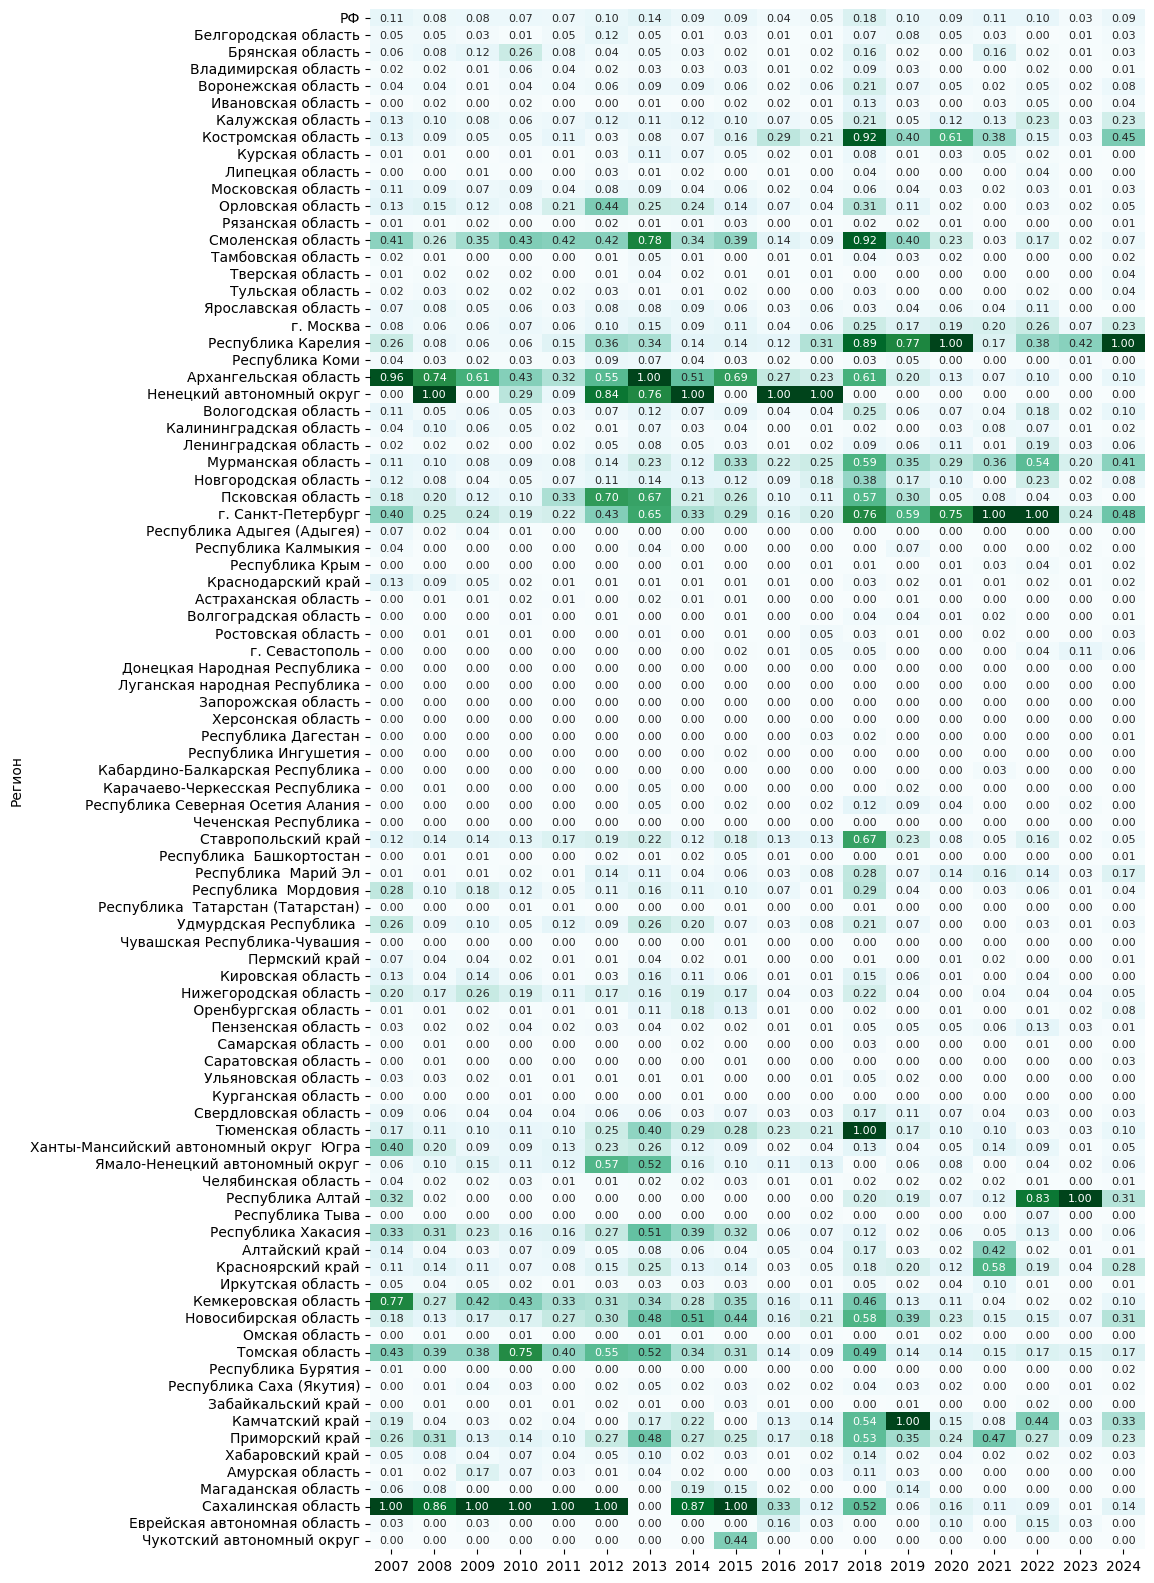

In [ ]:
plt.figure(figsize=(10, 20))
sns.heatmap(
    df_iersin_standardized.set_index('Регион'),
    cmap=sns.color_palette('BuGn', as_cmap=True),
    linewidth=0,
    cbar=False,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8}
)
plt.show()

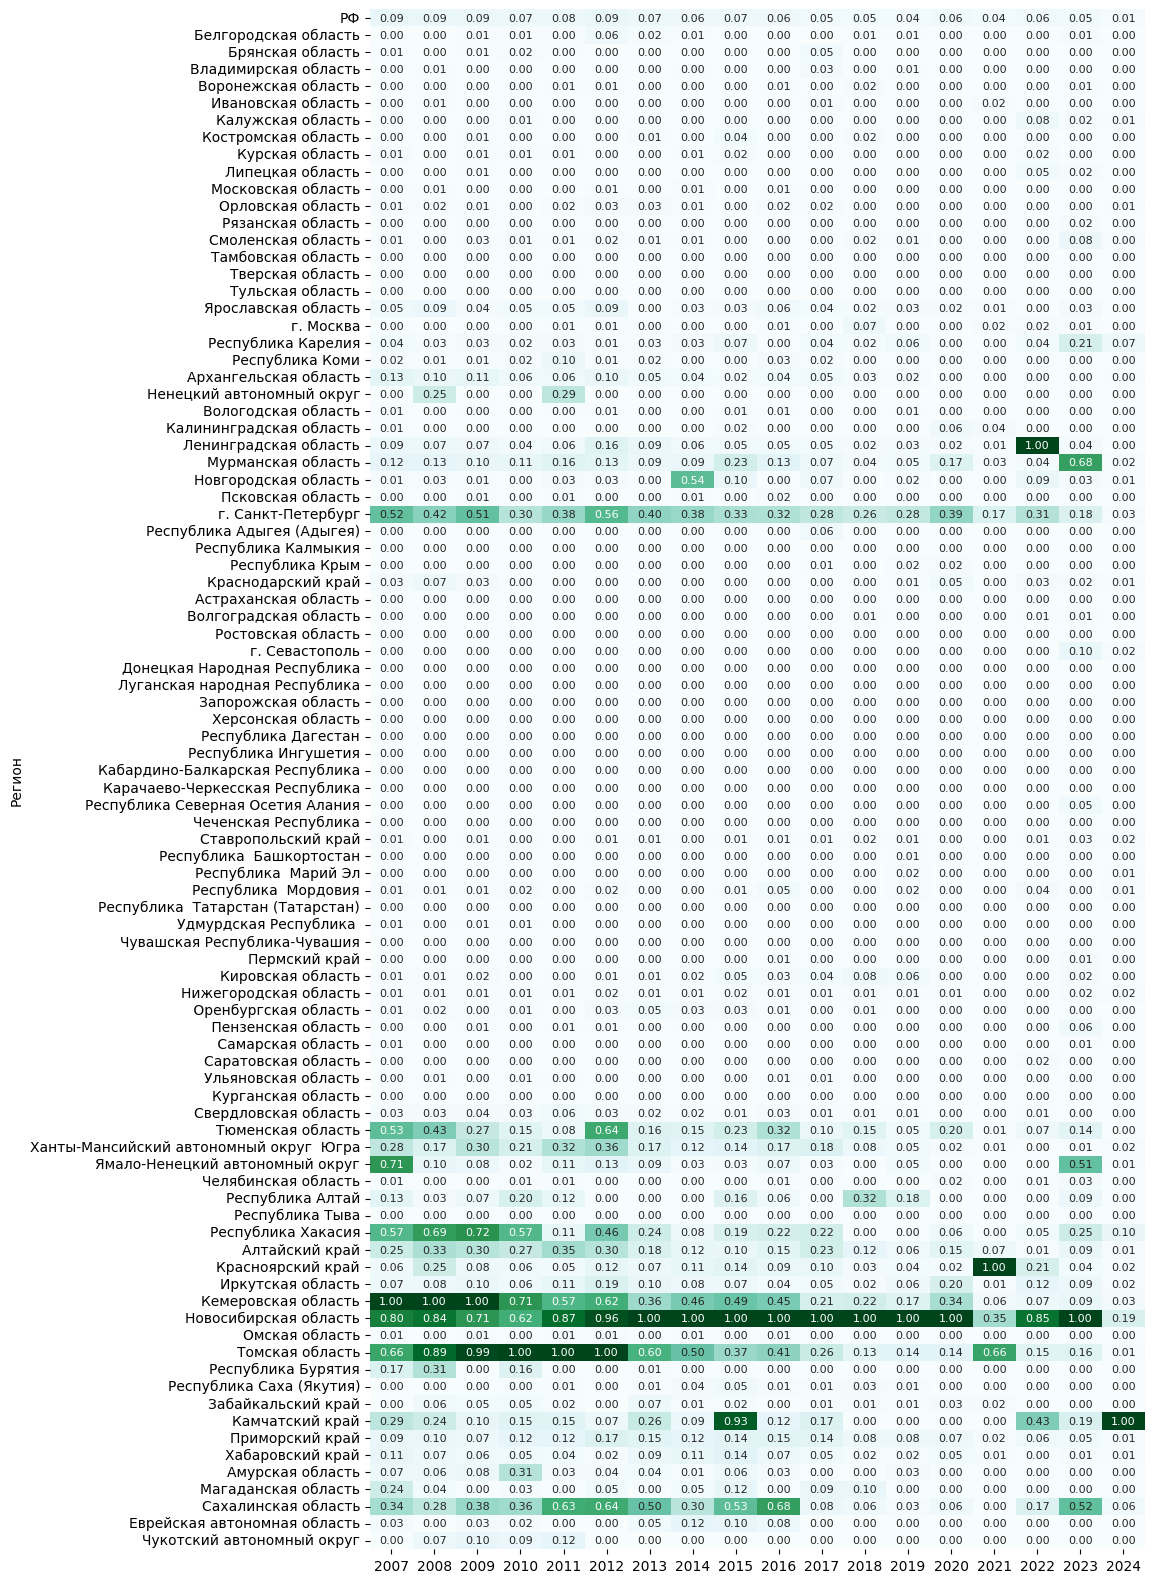

In [ ]:
plt.figure(figsize=(10,20))
sns.heatmap(
    df_pseudo_standardized.set_index('Регион'),
    cmap=sns.color_palette('BuGn', as_cmap=True),
    linewidth=0,
    cbar=False,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8}
)
plt.show()

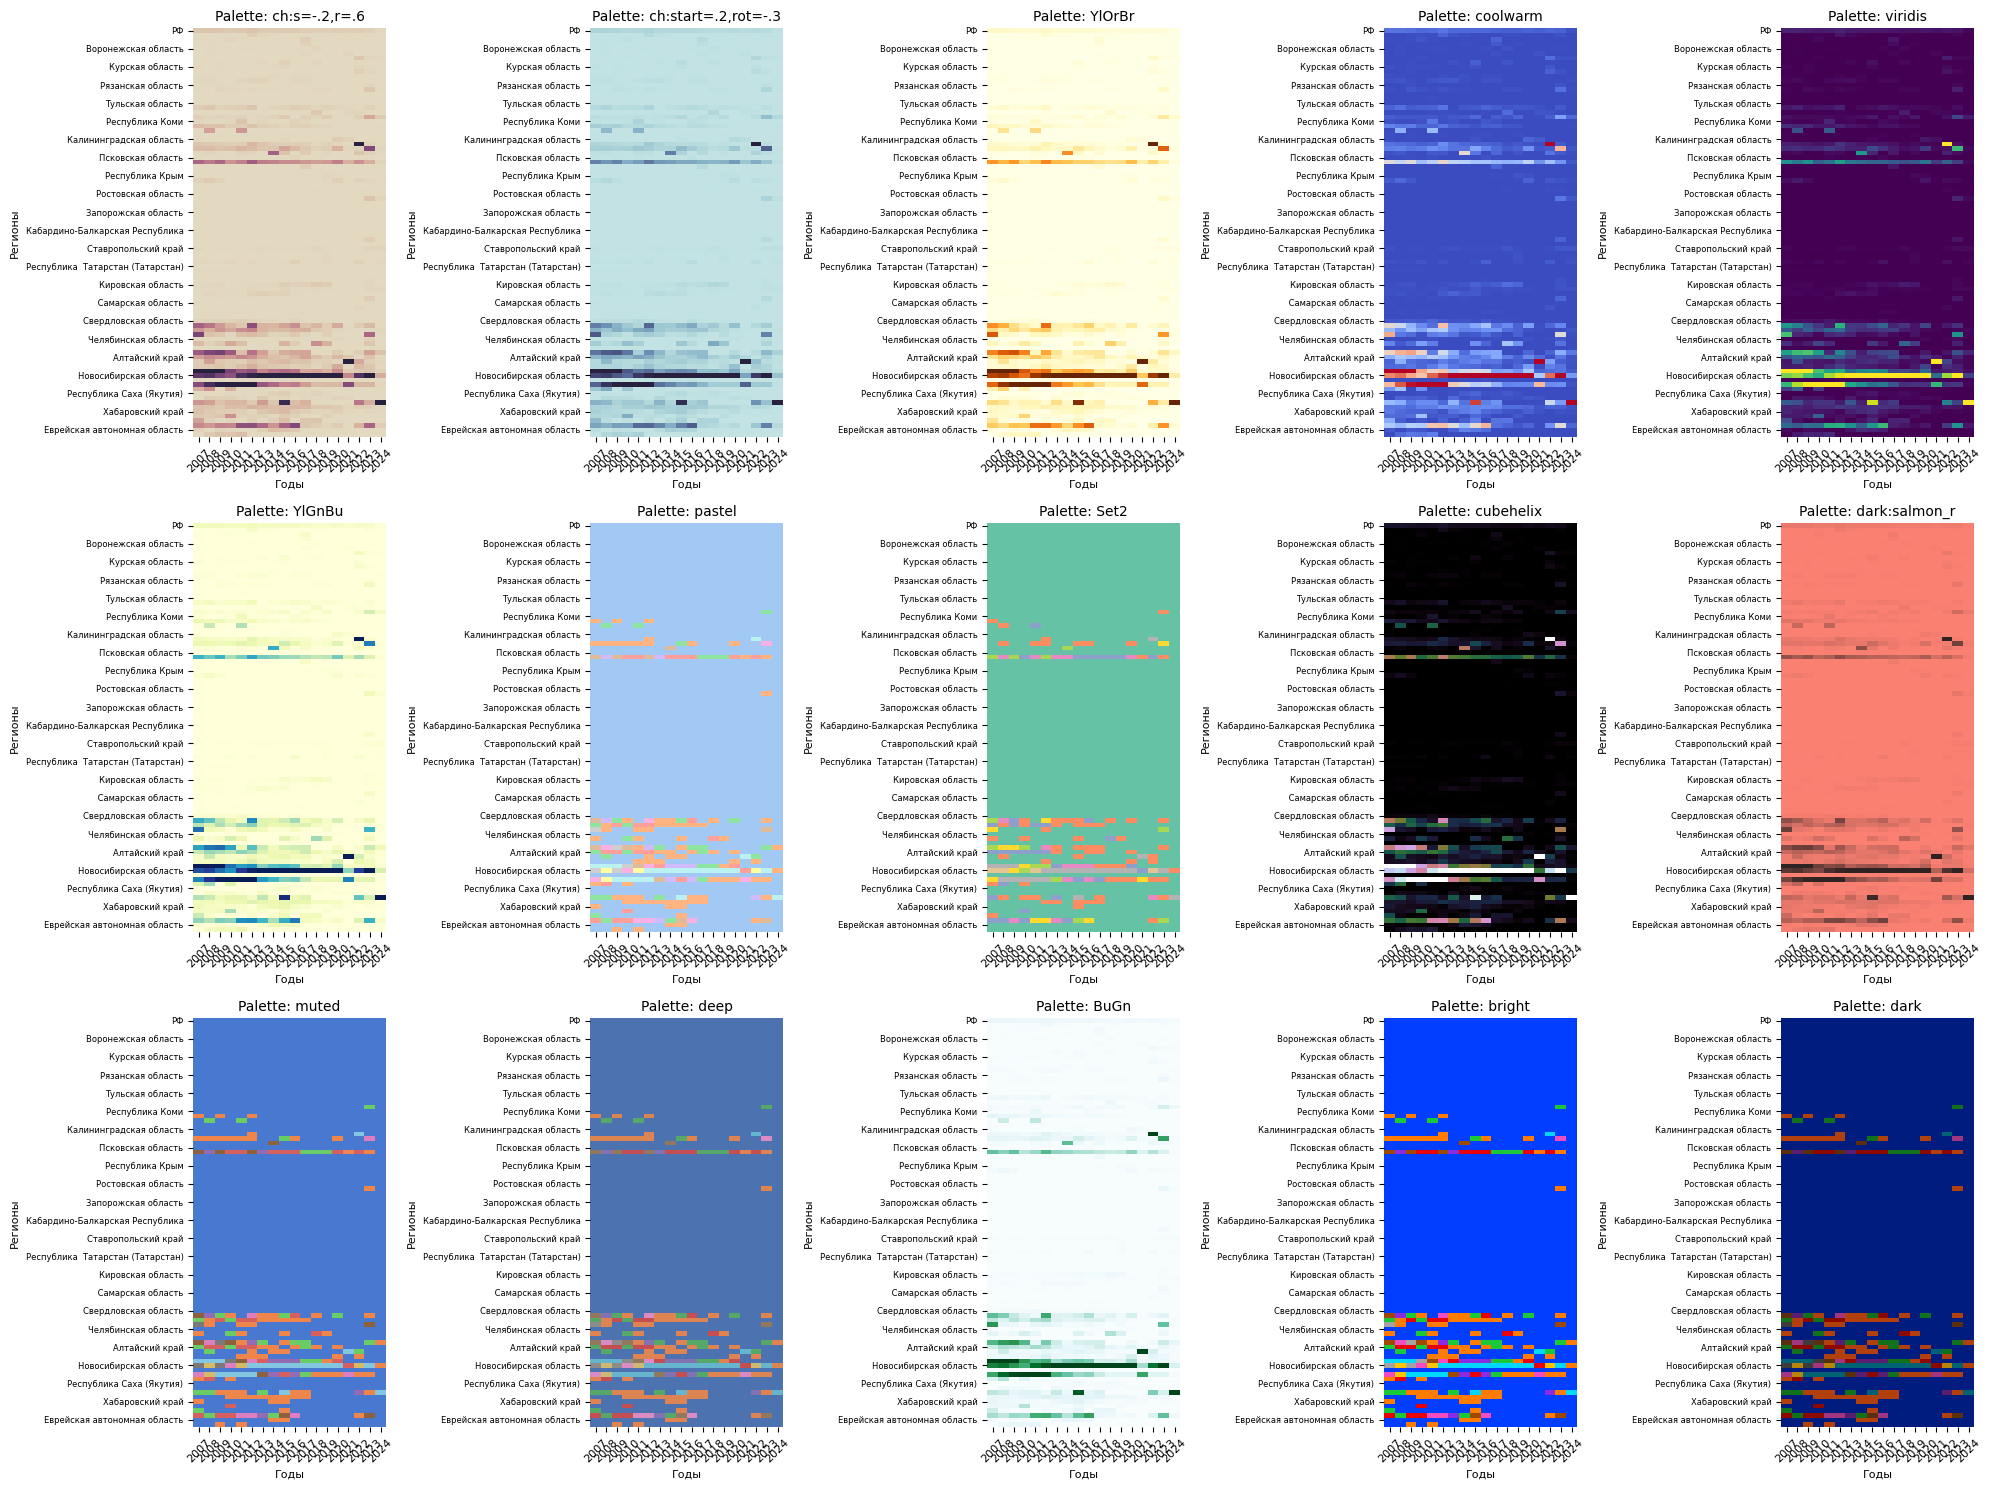

In [ ]:
palettes = [
    "ch:s=-.2,r=.6", "ch:start=.2,rot=-.3", "YlOrBr", "coolwarm", "viridis",
    "YlGnBu", "pastel", "Set2", "cubehelix", "dark:salmon_r",
    "muted", "deep", "BuGn", "bright", "dark"
]
fig, axes = plt.subplots(3, 5, figsize=(20, 15))
axes = axes.flatten()

for i, palette in enumerate(palettes):
    ax = axes[i]
    sns.heatmap(df_standardized.set_index('Регион'), annot=False,
                cmap=sns.color_palette(palette, as_cmap=True),
                linewidth=0, cbar=False, ax=ax)

    # Настройки для каждого графика
    ax.set_title(f'Palette: {palette}', fontsize=10)
    ax.set_xlabel('Годы', fontsize=8)
    ax.set_ylabel('Регионы', fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=6)

plt.tight_layout()
plt.show()

In [ ]:
pca = PCA(n_components=3)

X_iersin = df_iersin_standardized.iloc[:,:-1]
pca_result = pca.fit_transform(X_iersin)

pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2', 'PC3'])
pca_df['Регион'] = regions_iersin

fig = px.scatter_3d(pca_df, x='PC1', y='PC2', z='PC3', color='Регион',
                    title='PCA 3D Visualization',
                    labels={'PC1': 'Principal Component 1',
                            'PC2': 'Principal Component 2',
                            'PC3': 'Principal Component 3'})

fig.show()

In [ ]:
umap_model = umap.UMAP(n_components=3)
umap_result = umap_model.fit_transform(X_iersin)

umap_df = pd.DataFrame(umap_result, columns=['UMAP1', 'UMAP2', 'UMAP3'])
umap_df['Регион'] = regions_iersin

fig = px.scatter_3d(umap_df, x='UMAP1', y='UMAP2', z='UMAP3', color='Регион',
                    title='UMAP 3D Visualization',
                    labels={'UMAP1': 'UMAP Component 1',
                            'UMAP2': 'UMAP Component 2',
                            'UMAP3': 'UMAP Component 3'})

fig.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [ ]:
fig.write_html("umap_3d_visualization_iersin.html")

In [ ]:
pca = PCA(n_components=3)

X_pseudo = df_pseudo_standardized.iloc[:,:-1]
pca_result = pca.fit_transform(X_pseudo)

pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2', 'PC3'])
pca_df['Регион'] = regions_pseudo

fig = px.scatter_3d(pca_df, x='PC1', y='PC2', z='PC3', color='Регион',
                    title='PCA 3D Visualization',
                    labels={'PC1': 'Principal Component 1',
                            'PC2': 'Principal Component 2',
                            'PC3': 'Principal Component 3'})

fig.show()

In [ ]:
umap_model = umap.UMAP(n_components=3)
umap_result = umap_model.fit_transform(X_iersin)

umap_df = pd.DataFrame(umap_result, columns=['UMAP1', 'UMAP2', 'UMAP3'])
umap_df['Регион'] = regions_pseudo

fig = px.scatter_3d(umap_df, x='UMAP1', y='UMAP2', z='UMAP3', color='Регион',
                    title='UMAP 3D Visualization',
                    labels={'UMAP1': 'UMAP Component 1',
                            'UMAP2': 'UMAP Component 2',
                            'UMAP3': 'UMAP Component 3'})

fig.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [ ]:
fig.write_html("umap_3d_visualization_pseudo.html")

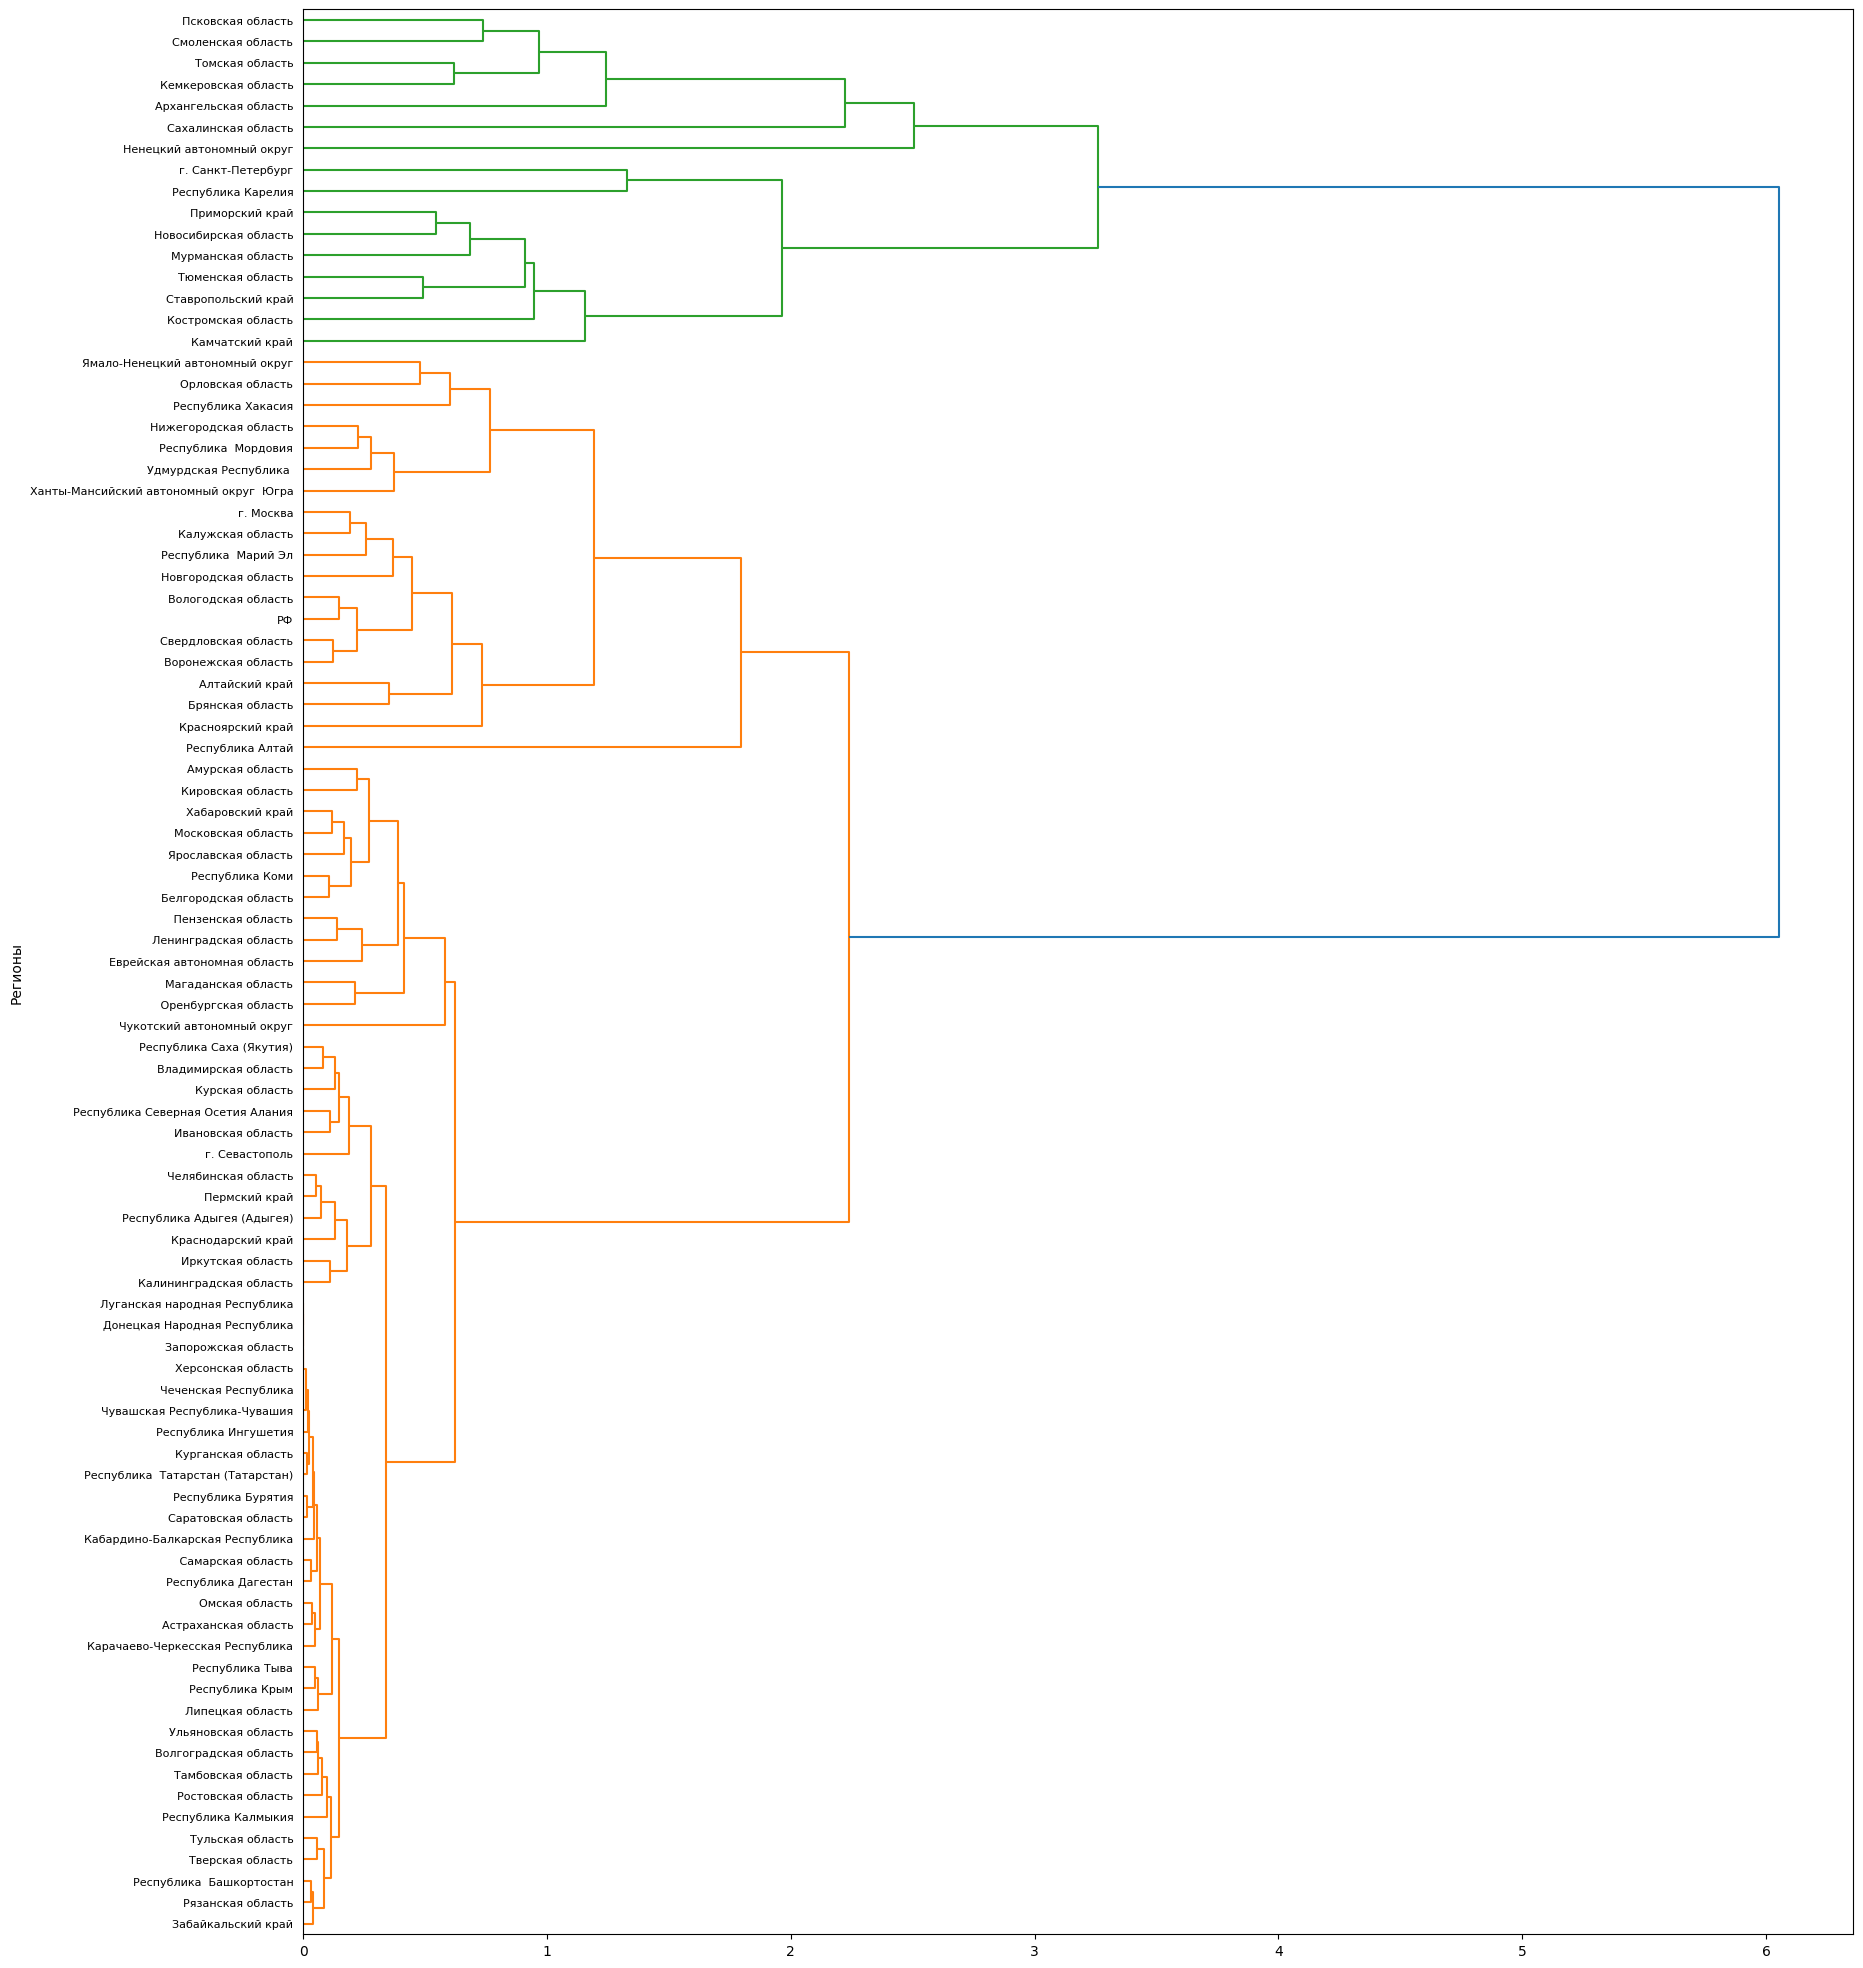

In [ ]:
# Иерархическая кластеризация
Z = linkage(X_iersin, method='ward')

# определяем число кластеров
num_clusters = int(max(Z[:, 3]))

# Создаем палитру
palette = sns.color_palette("husl", num_clusters)
cluster_colors = {i: palette[i % num_clusters] for i in range(len(Z) + 1)}

# Функция для окрашивания
def color_func(k):
    return cluster_colors.get(k, 'yellow')

# Построение дендрограммы
plt.figure(figsize=(20, 25))
dendrogram(Z, labels=regions_iersin.values, orientation='right', distance_sort='ascending')

plt.ylabel('Регионы')
plt.yticks(fontsize=8)
plt.show()


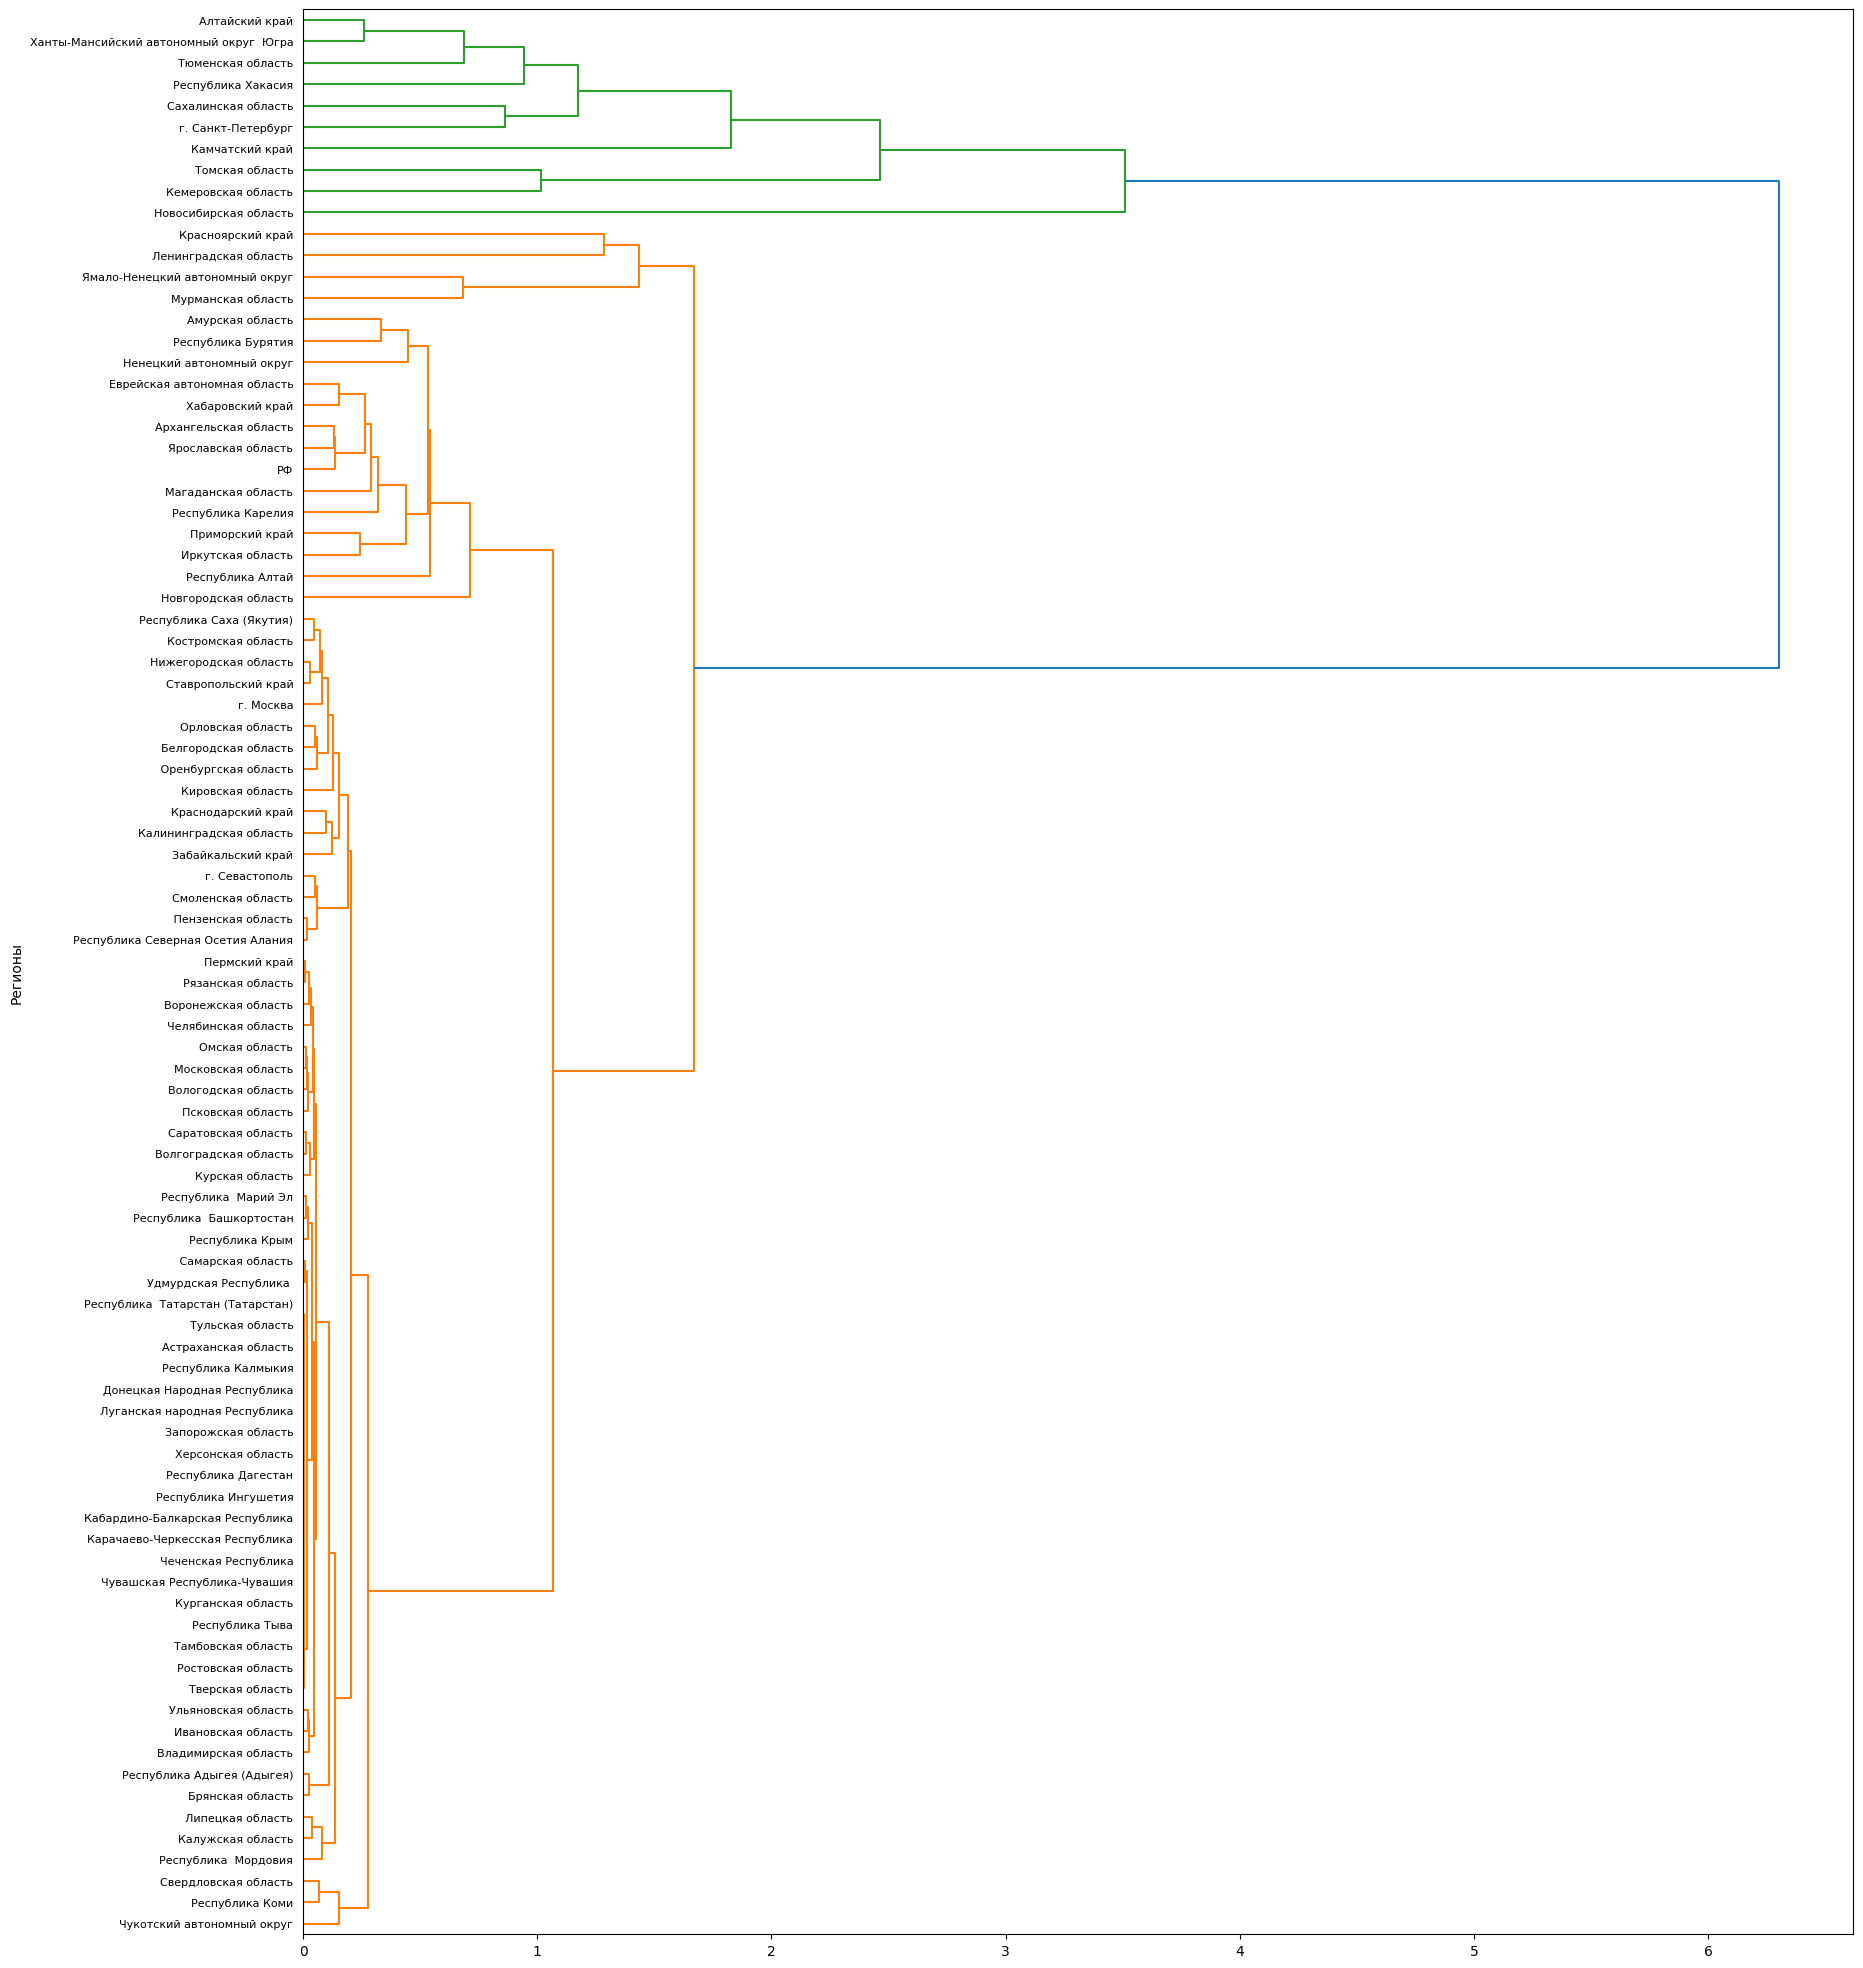

In [ ]:
# Иерархическая кластеризация
Z = linkage(X_pseudo, method='ward')

# определяем число кластеров
num_clusters = int(max(Z[:, 3]))

# Создаем палитру
palette = sns.color_palette("husl", num_clusters)
cluster_colors = {i: palette[i % num_clusters] for i in range(len(Z) + 1)}

# Функция для окрашивания
def color_func(k):
    return cluster_colors.get(k, 'yellow')

# Построение дендрограммы
plt.figure(figsize=(20, 25))
dendrogram(Z, labels=regions_pseudo.values, orientation='right', distance_sort='ascending')

plt.ylabel('Регионы')
plt.yticks(fontsize=8)
plt.show()


In [9]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# IERSIN
regions_iersin = df_iersin['Регион']
data_iersin = df_iersin.drop(columns=['Регион'])

scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

data_iersin_std = scaler_std.fit_transform(data_iersin)
data_iersin_scaled = scaler_minmax.fit_transform(data_iersin_std)

df_iersin_scaled = pd.DataFrame(data_iersin_scaled, columns=data_iersin.columns)
df_iersin_scaled['Регион'] = regions_iersin

df_iersin_scaled

,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,Регион
0,0.113371,0.080605,0.076997,0.074824,0.066534,0.100638,0.142395,0.089413,0.091988,0.042603,0.047724,0.182979,0.096545,0.086287,0.105263,0.103448,0.030882,0.086817,РФ
1,0.050330,0.047019,0.028216,0.008268,0.054582,0.115521,0.048544,0.013591,0.028932,0.010735,0.007131,0.068085,0.078252,0.049307,0.034211,0.000000,0.006373,0.032154,Белгородская область
2,0.057448,0.076826,0.117169,0.255064,0.078088,0.044649,0.051780,0.034335,0.023739,0.011070,0.018102,0.157447,0.017276,0.000000,0.155263,0.020690,0.008333,0.027331,Брянская область
3,0.017285,0.020151,0.013391,0.060356,0.038645,0.024805,0.030205,0.025036,0.031899,0.009728,0.019748,0.091489,0.029472,0.000000,0.000000,0.018391,0.003431,0.011254,Владимирская область
4,0.041688,0.042401,0.014825,0.036379,0.044223,0.060950,0.088457,0.088698,0.057122,0.024488,0.056500,0.210638,0.074187,0.046225,0.023684,0.050575,0.015196,0.077170,Воронежская область
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,0.005592,0.019312,0.171210,0.066970,0.028685,0.008505,0.039914,0.017883,0.000000,0.004025,0.034010,0.106383,0.025407,0.000000,0.000000,0.000000,0.000000,0.000000,Амурская область
86,0.059990,0.075147,0.000000,0.000000,0.000000,0.000000,0.000000,0.188841,0.149110,0.022811,0.000000,0.000000,0.142276,0.000000,0.000000,0.000000,0.000000,0.000000,Магаданская область
87,1.000000,0.856003,1.000000,1.000000,1.000000,1.000000,0.000000,0.871960,1.000000,0.330091,0.123971,0.523404,0.061992,0.157165,0.107895,0.094253,0.010784,0.138264,Сахалинская область
88,0.027453,0.000000,0.025825,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.160349,0.033461,0.000000,0.000000,0.097072,0.000000,0.147126,0.032843,0.000000,Еврейская автономная область


In [ ]:
# Создаем DataFrame из UMAP-результатов и кластеров
umap_df_iersin = pd.DataFrame(umap_result_iersin, columns=['UMAP1', 'UMAP2'])
umap_df_iersin['Cluster'] = clusters
umap_df_iersin['Регион'] = regions_iersin.values  # Вернем регионы

# Преобразуем -1 (шум) в 'Noise'
umap_df_iersin['Cluster'] = umap_df_iersin['Cluster'].apply(lambda x: f'Cluster {x}' if x != -1 else 'Noise')

# Строим интерактивный график
fig = px.scatter(
    umap_df_iersin,
    x='UMAP1',
    y='UMAP2',
    color='Cluster',
    hover_data=['Регион'],
    title='UMAP + HDBSCAN Clustering (Interactive)',
    labels={'UMAP1': 'UMAP Component 1', 'UMAP2': 'UMAP Component 2'},
    opacity=0.9
)

fig.update_layout(legend_title='Cluster', width=900, height=700)
fig.show()

# Сохраняем результат в html
fig.write_html("umap_hdbscan_iersin.html")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



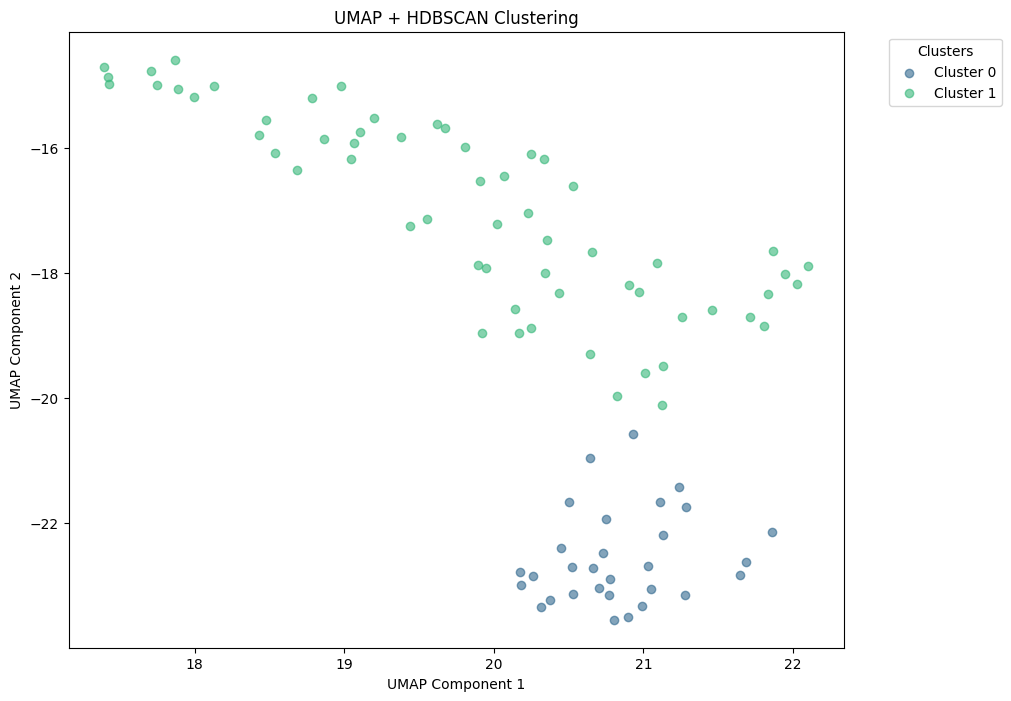

Silhouette Score: 0.616


In [ ]:
# Применяем UMAP для снижения размерности
umap_model = umap.UMAP(n_components=2, random_state=42)
umap_result_pseudo = umap_model.fit_transform(X_pseudo)

# Применяем HDBSCAN
hdb = hdbscan.HDBSCAN(min_cluster_size=4)
clusters_pseudo = hdb.fit_predict(umap_result_pseudo)

# Генерация цветов для кластеров
num_clusters_pseudo = len(set(clusters_pseudo)) - (1 if -1 in clusters_pseudo else 0)  # исключаем шум (-1)
palette_pseudo = sns.color_palette("viridis", num_clusters_pseudo) if num_clusters_pseudo > 0 else sns.color_palette("husl", 1)

# Составляем словарь цветов для кластеров
cluster_colors_pseudo = {i: mcolors.to_hex(palette_pseudo[i % num_clusters_pseudo]) for i in range(num_clusters_pseudo)}
cluster_colors_pseudo[-1] = "#000000"  # Шум окрашиваем в черный цвет

# Визуализация кластеров
plt.figure(figsize=(10, 8))

# Для каждого кластера отобразим его точки с заданным цветом
for cluster in set(clusters_pseudo):
    mask = clusters_pseudo == cluster
    plt.scatter(umap_result_pseudo[mask, 0], umap_result_pseudo[mask, 1],
                color=cluster_colors_pseudo[cluster], label=f'Cluster {cluster}' if cluster != -1 else 'Noise', alpha=0.6)

# Настройка графика
plt.title('UMAP + HDBSCAN Clustering')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')

# Легенда с точным описанием
plt.legend(title="Clusters", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

# Вычисление и вывод Silhouette Score
# Игнорируем шум (-1), потому что silhouette_score работает только для кластеров
valid_clusters_pseudo = clusters_pseudo[clusters_pseudo != -1]

if len(set(valid_clusters_pseudo)) > 1:
    score = silhouette_score(umap_result_pseudo[clusters_pseudo != -1], valid_clusters_pseudo)
    print(f'Silhouette Score: {score:.3f}')
else:
    print('Silhouette Score cannot be calculated with a single cluster or noise.')

In [ ]:
# Создаем DataFrame из UMAP-результатов и кластеров
umap_df_pseudo = pd.DataFrame(umap_result_pseudo, columns=['UMAP1', 'UMAP2'])
umap_df_pseudo['Cluster'] = clusters_pseudo
umap_df_pseudo['Регион'] = regions_pseudo.values  # Вернем регионы

# Преобразуем -1 (шум) в 'Noise'
umap_df_pseudo['Cluster'] = umap_df_pseudo['Cluster'].apply(lambda x: f'Cluster {x}' if x != -1 else 'Noise')

# Строим интерактивный график
fig = px.scatter(
    umap_df_pseudo,
    x='UMAP1',
    y='UMAP2',
    color='Cluster',
    hover_data=['Регион'],
    title='UMAP + HDBSCAN Clustering (Interactive)',
    labels={'UMAP1': 'UMAP Component 1', 'UMAP2': 'UMAP Component 2'},
    opacity=0.9
)

fig.update_layout(legend_title='Cluster', width=900, height=700)
fig.show()

# Сохраняем результат в html
fig.write_html("umap_hdbscan_pseudo.html")
